In [ ]:
from google.colab import files
uploaded = files.upload()

Saving paddydataset.csv to paddydataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv('paddydataset.csv')

# Display the first 5 rows
df.head()

,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


In [ ]:
# Dataset information
df.info()

# Shape of the dataset
print(df.shape)

# Check for missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2789 entries, 0 to 2788
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Hectares                            2789 non-null   int64  
 1   Agriblock                           2789 non-null   object 
 2   Variety                             2789 non-null   object 
 3   Soil Types                          2789 non-null   object 
 4   Seedrate(in Kg)                     2789 non-null   int64  
 5   LP_Mainfield(in Tonnes)             2789 non-null   float64
 6   Nursery                             2789 non-null   object 
 7   Nursery area (Cents)                2789 non-null   int64  
 8   LP_nurseryarea(in Tonnes)           2789 non-null   int64  
 9   DAP_20days                          2789 non-null   int64  
 10  Weed28D_thiobencarb                 2789 non-null   int64  
 11  Urea_40Days                         2789 no

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define target and features
target = 'Paddy yield(in Kg)'
features = df.drop(columns=[target]).columns

# Separate features and target
X = df[features]
y = df[target]

In [ ]:
# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=np.number).columns

# Apply one-hot encoding to categorical features
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

display(X_encoded.head())

,Hectares,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,Weed28D_thiobencarb,Urea_40Days,Potassh_50Days,Micronutrients_70Days,...,Wind Direction_D31_D60_WNW,Wind Direction_D61_D90_NNE,Wind Direction_D61_D90_NNW,Wind Direction_D61_D90_SE,Wind Direction_D61_D90_SW,Wind Direction_D91_D120_NW,Wind Direction_D91_D120_S,Wind Direction_D91_D120_SSE,Wind Direction_D91_D120_W,Wind Direction_D91_D120_WSW
0,6,150,75.0,120,6,240,12,162.78,62.28,90,...,False,False,True,False,False,False,False,False,False,True
1,6,150,75.0,120,6,240,12,162.78,62.28,90,...,False,False,False,True,False,False,False,True,False,False
2,6,150,75.0,120,6,240,12,162.78,62.28,90,...,False,True,False,False,False,False,False,False,True,False
3,6,150,75.0,120,6,240,12,162.78,62.28,90,...,True,False,False,True,False,False,True,False,False,False
4,6,150,75.0,120,6,240,12,162.78,62.28,90,...,False,False,False,False,True,True,False,False,False,False


In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')

Mean Squared Error: 786472.22
R-squared: 0.99


In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test)

# Evaluate the model
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f'Linear Regression Mean Squared Error: {mse_linear:.2f}')
print(f'Linear Regression R-squared: {r2_linear:.2f}')

Linear Regression Mean Squared Error: 861065.18
Linear Regression R-squared: 0.99


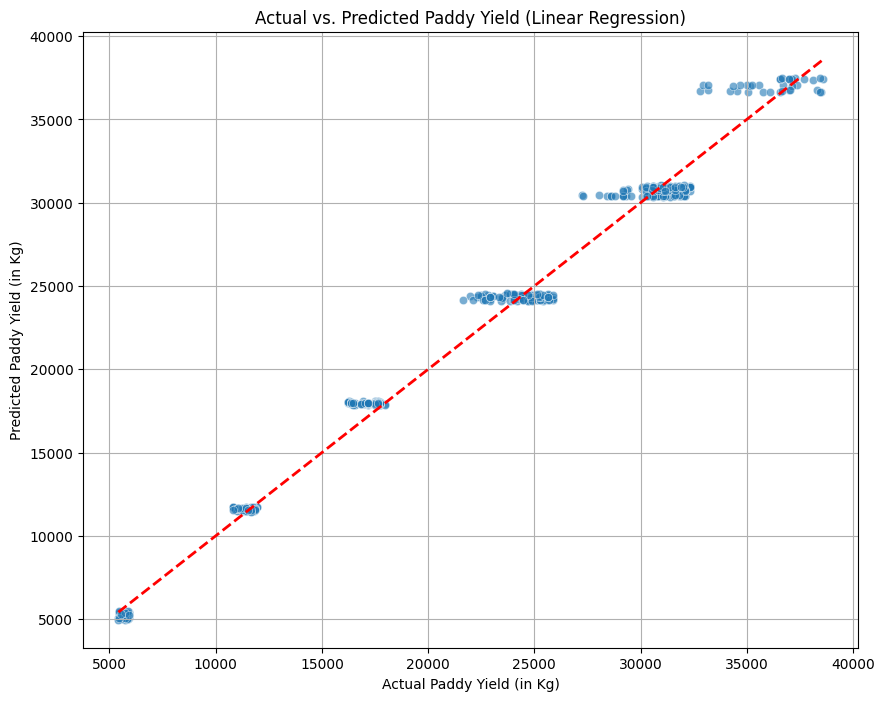

In [ ]:
# Create a scatter plot of actual vs. predicted values for Linear Regression
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred_linear, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Add a perfect prediction line
plt.xlabel('Actual Paddy Yield (in Kg)')
plt.ylabel('Predicted Paddy Yield (in Kg)')
plt.title('Actual vs. Predicted Paddy Yield (Linear Regression)')
plt.grid(True)
plt.show()